In [1]:
import json
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd

In [2]:
def build_choose_project_dataframe(
    actions_path: str | Path,
    observations_path: str | Path,
    seed: int | None = None,
    reward_scheme: str | None = None,
) -> pd.DataFrame:

    rows = []
    skipped = 0

    with open(actions_path, "r", encoding="utf-8") as f_act, open(observations_path, "r", encoding="utf-8") as f_obs:
        for step, (act_line, obs_line) in enumerate(zip(f_act, f_obs)):
            act = json.loads(act_line)
            obs = json.loads(obs_line)

            # skip broken / terminal / empty rows
            if obs is None or act is None:
                skipped += 1
                continue

            if "agent_0" not in obs or "agent_0" not in act:
                skipped += 1
                continue

            if obs["agent_0"] is None or act["agent_0"] is None:
                skipped += 1
                continue

            if "observation" not in obs["agent_0"] or "action_mask" not in obs["agent_0"]:
                skipped += 1
                continue

            if "choose_project" not in act["agent_0"]:
                skipped += 1
                continue

            agent_obs = obs["agent_0"]["observation"]
            action_mask = obs["agent_0"]["action_mask"]

            project_opportunities = agent_obs["project_opportunities"]
            chosen_project_idx = act["agent_0"]["choose_project"]

            # projects are numbered from 0 to n-1 in observation, 
            # but action choose_project is 0 (no project) or 1..n (project_0..project_{n-1})
            for i, (proj_key, proj_data) in enumerate(project_opportunities.items()):
                # i matches the index in action_mask["choose_project"][1:]
                # or project_{i} in observations
                
                rows.append({
                    "seed": seed,
                    "reward_scheme": reward_scheme,
                    "step": step,
                    "project_idx": i,
                    "selected": 1 if chosen_project_idx == (i + 1) else 0,
                    "required_effort": proj_data["required_effort"][0],
                    "prestige": proj_data["prestige"][0],
                    "novelty": proj_data["novelty"][0],
                    "time_window": proj_data["time_window"][0],
                    "action_mask": action_mask["choose_project"][i+1],
                })

    if skipped > 0:
        print(f"[INFO] Seed {seed}: skipped {skipped} invalid rows")

    return pd.DataFrame(rows)

def build_choose_project_dataframe_for_seeds(
    log_dir: str | Path,
    reward_scheme: str,
    seeds: list[int],
) -> pd.DataFrame:
    """
    Build one combined choose_project dataframe over multiple seeds.
    Expected filenames:
    rl_ppo_{reward_scheme}_s{seed}_actions.jsonl
    rl_ppo_{reward_scheme}_s{seed}_observations.jsonl
    """

    log_dir = Path(log_dir)
    dfs = []

    for seed in seeds:
        actions_path = log_dir / f"rl_ppo_{reward_scheme}_s{seed}_actions.jsonl"
        observations_path = log_dir / f"rl_ppo_{reward_scheme}_s{seed}_observations.jsonl"

        if not actions_path.exists() or not observations_path.exists():
            print(f"[WARN] Missing files for seed {seed}: {actions_path.name} / {observations_path.name}")
            continue

        df_seed = build_choose_project_dataframe(
            actions_path=actions_path,
            observations_path=observations_path,
            seed=seed,
            reward_scheme=reward_scheme,
        )

        dfs.append(df_seed)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [3]:
seeds = list(range(101, 111))

project_df = build_choose_project_dataframe_for_seeds(
    log_dir="../log",
    reward_scheme="by_effort",
    seeds=seeds,
)

[INFO] Seed 102: skipped 580 invalid rows
[INFO] Seed 103: skipped 45 invalid rows
[INFO] Seed 104: skipped 534 invalid rows
[INFO] Seed 105: skipped 530 invalid rows
[INFO] Seed 107: skipped 23 invalid rows
[INFO] Seed 108: skipped 165 invalid rows
[INFO] Seed 109: skipped 541 invalid rows
[INFO] Seed 110: skipped 97 invalid rows


In [4]:
project_df

,seed,reward_scheme,step,project_idx,selected,required_effort,prestige,novelty,time_window,action_mask
0,101,by_effort,0,0,1,32,0.439810,0.241280,50,0
1,101,by_effort,1,0,0,24,0.603742,0.244144,34,0
2,101,by_effort,2,0,0,28,0.594894,0.254707,53,1
3,101,by_effort,3,0,1,18,0.423703,0.183052,33,1
4,101,by_effort,4,0,1,12,0.232656,0.208934,20,1
...,...,...,...,...,...,...,...,...,...,...
3480,110,by_effort,498,0,0,28,0.537531,0.213078,45,1
3481,110,by_effort,499,0,1,19,0.560612,0.230075,36,0
3482,110,by_effort,500,0,0,49,0.787128,0.184438,68,0
3483,110,by_effort,501,0,0,15,0.391708,0.207909,29,1


In [5]:
def build_step_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate project-level dataframe to step-level statistics.
    One row = one seed-step.
    """

    group_cols = ["seed", "step"] if "seed" in df.columns else ["step"]
    # only rows where a project was selectable
    grouped = df[df["action_mask"] == 1].groupby(group_cols)

    summary = grouped.apply(lambda g: pd.Series({
        "n_projects": len(g),
        "any_selected": 1 if g["selected"].sum() > 0 else 0,

        "mean_selected_prestige": g[g["selected"] == 1]["prestige"].mean(),
        "mean_unselected_prestige": g[g["selected"] == 0]["prestige"].mean(),

        "mean_selected_novelty": g[g["selected"] == 1]["novelty"].mean(),
        "mean_unselected_novelty": g[g["selected"] == 0]["novelty"].mean(),

        "mean_selected_effort": g[g["selected"] == 1]["required_effort"].mean(),
        "mean_unselected_effort": g[g["selected"] == 0]["required_effort"].mean(),
    }))

    return summary.reset_index()

In [6]:
summary = build_step_summary(project_df)

In [7]:
summary.describe()

,seed,step,n_projects,any_selected,mean_selected_prestige,mean_unselected_prestige,mean_selected_novelty,mean_unselected_novelty,mean_selected_effort,mean_unselected_effort
count,1390.000000,1390.000000,1390.0,1390.000000,608.000000,782.000000,608.000000,782.000000,608.000000,782.000000
mean,105.811511,252.043885,1.0,0.437410,0.500811,0.501893,0.231264,0.225893,25.680921,24.494885
std,3.039293,166.217771,0.0,0.496246,0.151723,0.147641,0.065744,0.063384,12.913736,12.533462
min,101.000000,0.000000,1.0,0.000000,0.100000,0.100000,0.112946,0.104331,1.000000,2.000000
25%,103.000000,107.250000,1.0,0.000000,0.400597,0.406238,0.182629,0.178155,17.000000,16.000000
50%,106.000000,248.000000,1.0,0.000000,0.506274,0.503434,0.218407,0.215678,24.000000,22.000000
75%,108.000000,387.000000,1.0,1.000000,0.600100,0.598471,0.267149,0.262765,32.000000,31.000000
max,110.000000,599.000000,1.0,1.000000,1.000000,0.896625,0.557731,0.560825,82.000000,88.000000


## Vergleich der Durchschnittswerte von ausgewählten vs. nicht ausgewählten Projekten:
- Prestige: Bevorzugt der Agent prestigeträchtigere Projekte?
- Neuheit: Bevorzugt der Agent neuere Projekte?
- Aufwand: Bevorzugt der Agent Projekte mit weniger Aufwand?

In [8]:
summary[[
    "mean_selected_prestige",
    "mean_unselected_prestige",
    "mean_selected_novelty",
    "mean_unselected_novelty",
    "mean_selected_effort",
    "mean_unselected_effort",
]].mean()

mean_selected_prestige       0.500811
mean_unselected_prestige     0.501893
mean_selected_novelty        0.231264
mean_unselected_novelty      0.225893
mean_selected_effort        25.680921
mean_unselected_effort      24.494885
dtype: float64

## Logistische Regression: Können wir die Auswahl eines Projekts basierend auf den Beobachtungen vorhersagen?


In [9]:
# Logistic Regression: Can we predict the selection based on observations?
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
    "time_window",
]

features = project_df[feature_cols]
target = project_df["selected"]

model = LogisticRegression(max_iter=1000)
model.fit(features, target)

print(dict(zip(feature_cols, model.coef_[0])))

{'required_effort': np.float64(0.00912659816001018), 'prestige': np.float64(0.07721879248184035), 'novelty': np.float64(1.0026678596876186), 'time_window': np.float64(-0.0034614874183985468)}


## Koeffizienten

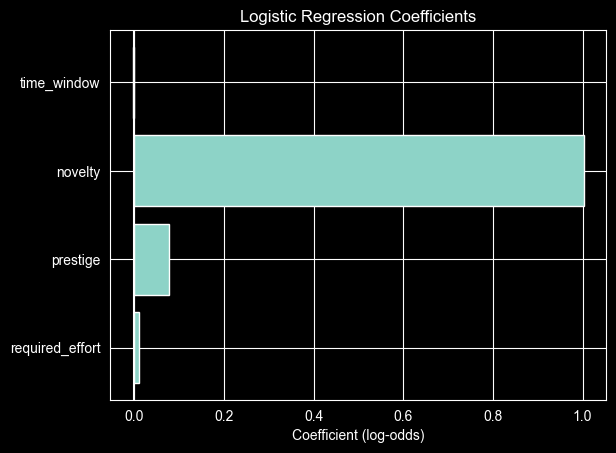

In [10]:
coefs = model.coef_[0]

plt.figure()
plt.barh(feature_cols, coefs)
plt.xlabel("Coefficient (log-odds)")
plt.title("Logistic Regression Coefficients")
plt.axvline(0)
plt.show()

## Probability vs Feature


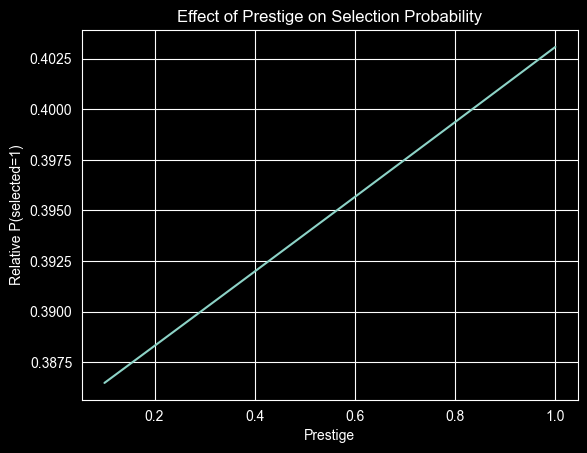

In [13]:
# Range für prestige
x_vals = np.linspace(
    project_df["prestige"].min(),
    project_df["prestige"].max(),
    100
)

# Mittelwerte der Features als Basis
mean_vals = features.mean().copy()

# Input DataFrame erzeugen (vectorized)
df_inputs = pd.DataFrame([mean_vals] * len(x_vals))
df_inputs["prestige"] = x_vals

# Wahrscheinlichkeiten berechnen
probs = model.predict_proba(df_inputs)[:, 1]

# Plot
plt.figure()
plt.plot(x_vals, probs)
plt.xlabel("Prestige")
plt.ylabel("Relative P(selected=1)")
plt.title("Effect of Prestige on Selection Probability")
# plt.ylim(0, 1)
plt.show()

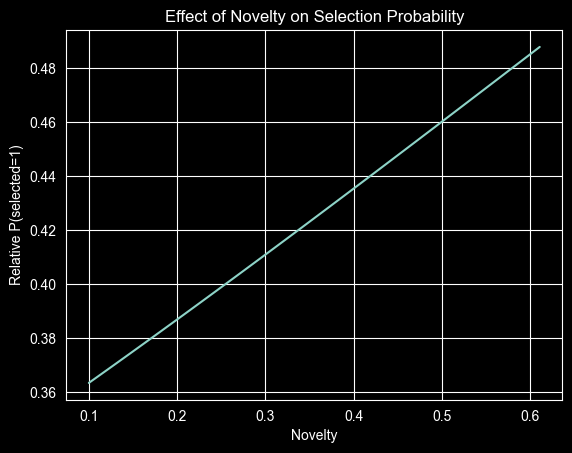

In [14]:
# Range für novelty
x_vals = np.linspace(
    project_df["novelty"].min(),
    project_df["novelty"].max(),
    100
)

# Mittelwerte der Features als Basis
mean_vals = features.mean().copy()

# Input DataFrame erzeugen (vectorized)
df_inputs = pd.DataFrame([mean_vals] * len(x_vals))
df_inputs["novelty"] = x_vals

# Wahrscheinlichkeiten berechnen
probs = model.predict_proba(df_inputs)[:, 1]

# Plot
plt.figure()
plt.plot(x_vals, probs)
plt.xlabel("Novelty")
plt.ylabel("Relative P(selected=1)")
plt.title("Effect of Novelty on Selection Probability")
plt.show()

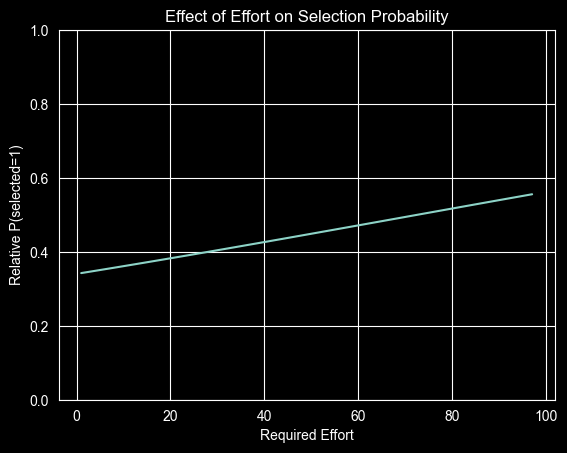

In [15]:
# Range für required_effort
x_vals = np.linspace(
    project_df["required_effort"].min(),
    project_df["required_effort"].max(),
    100
)

# Mittelwerte der Features als Basis
mean_vals = features.mean().copy()

# Input DataFrame erzeugen (vectorized)
df_inputs = pd.DataFrame([mean_vals] * len(x_vals))
df_inputs["required_effort"] = x_vals

# Wahrscheinlichkeiten berechnen
probs = model.predict_proba(df_inputs)[:, 1]

# Plot
plt.figure()
plt.plot(x_vals, probs)
plt.xlabel("Required Effort")
plt.ylabel("Relative P(selected=1)")
plt.title("Effect of Effort on Selection Probability")
plt.ylim(0, 1)
plt.show()

## Standardisierte Koeffizienten

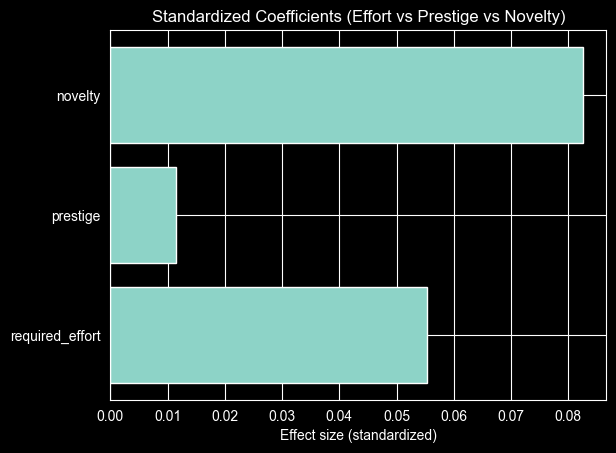

In [16]:
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
]

features = project_df[feature_cols]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(features_scaled, target)

plt.figure()
plt.barh(feature_cols, model_scaled.coef_[0])
plt.title("Standardized Coefficients (Effort vs Prestige vs Novelty)")
plt.xlabel("Effect size (standardized)")
plt.axvline(0)
plt.show()

Effort, prestige and novelty are expected to be the main drivers for project selection.

## Permutation importance: Wie stark beeinflusst jedes Feature die Vorhersage des Modells?


In [19]:
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
    "time_window",
]
features = project_df[feature_cols]

# Permutation importance
result = permutation_importance(model, features, target, n_repeats=10)

for i, col in enumerate(features.columns):
    print(col, result.importances_mean[i])

required_effort 0.0014347202295552862
prestige -0.00022955523672880674
novelty 0.00031563845050218696
time_window -8.608321377325811e-05


In [20]:
# Counterfactual: What if we swap the prestige values?
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
    "time_window",
]

features = project_df[feature_cols]
target = project_df["selected"]

model = LogisticRegression(max_iter=1000)
model.fit(features, target)

df_test = project_df.copy()
df_test["prestige"] = np.random.permutation(df_test["prestige"].values)

orig_prob = model.predict_proba(project_df[feature_cols])[:, 1]
new_prob = model.predict_proba(df_test[feature_cols])[:, 1]

change = np.abs(orig_prob - new_prob).mean()
print("Avg prob change (Prestige swap):", change)

Avg prob change (Prestige swap): 0.0030521822280529516


In [21]:
feature_cols = [
    "required_effort",
    "prestige",
    "novelty",
    "time_window",
]

features = project_df[feature_cols]
target = project_df["selected"]

model = LogisticRegression(max_iter=1000)
model.fit(features, target)

for col in feature_cols:
    df_test = project_df.copy()
    df_test[col] = np.random.permutation(df_test[col].values)

    orig_prob = model.predict_proba(project_df[feature_cols])[:, 1]
    new_prob = model.predict_proba(df_test[feature_cols])[:, 1]

    change = np.abs(orig_prob - new_prob).mean()
    print(col, change)

required_effort 0.029347121380620105
prestige 0.0030231640339938633
novelty 0.0165763237894326
time_window 0.017297035757733177
